# IMPORTS

In [24]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from diive.core.io.files import save_parquet, load_parquet
from diive.core.times.times import TimestampSanitizer

# LOAD DATA

In [25]:
partitioning_results = "Regular_Partition/NEE_XG-GAPF_PART_ReddyProc-20251006.csv"
results = pd.read_csv(partitioning_results)
results = results.set_index("TIMESTAMP")
results.index.name = "TIMESTAMP_END"
results = TimestampSanitizer(data=results).get()
results

,Tair_orig,Tair_f,Tair_fqc,Tair_fall,Tair_fall_qc,Tair_fnum,Tair_fsd,Tair_fmeth,Tair_fwin,Rg_orig,Rg_f,Rg_fqc,Rg_fall,Rg_fall_qc,Rg_fnum,...,FP_GPP2000,FP_k,FP_beta,FP_alpha,FP_RRef,FP_E0,FP_k_sd,FP_beta_sd,FP_alpha_sd,FP_RRef_sd,FP_E0_sd,Reco_DT_B,GPP_DT_B,Reco_DT_B_SD,GPP_DT_B_SD
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 23:15:00,0.466667,0.466667,0,0.466667,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.238158,0.0000,0.078769,0.000000
2023-11-08 23:45:00,0.266667,0.266667,0,0.266667,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.219322,0.0000,0.080369,0.000000
2023-11-09 00:15:00,0.600000,0.600000,0,0.600000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.250713,0.0000,0.077734,0.000000
2023-11-09 00:45:00,0.800000,0.800000,0,0.800000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.269542,0.0000,0.076233,0.000000
2023-11-09 01:15:00,0.633333,0.633333,0,0.633333,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.253851,0.0000,0.077479,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-02 19:45:00,15.186667,15.186667,0,15.186667,NaN,NaN,NaN,NaN,NaN,1.421245,1.421245,0,1.421245,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.244184,0.1618,0.439378,0.011361
2025-06-02 20:15:00,14.843333,14.843333,0,14.843333,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.134560,0.0000,0.443741,0.000000
2025-06-02 20:45:00,14.820000,14.820000,0,14.820000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.127118,0.0000,0.444092,0.000000


# Identify GPP and RECO columns

In [26]:
partcols = [c for c in results.columns if any(substring in c for substring in ["GPP", "Reco"])];
partcols = [c for c in partcols if not str(c).endswith("_fqc") and not str(c).endswith("_SD")] 
partcols.remove("FP_GPP2000")
partcols

['Reco_A',
 'GPP_A_f',
 'Reco_DT_A',
 'GPP_DT_A',
 'Reco_B',
 'GPP_B_f',
 'Reco_DT_B',
 'GPP_DT_B']

# Create subset with GPP and RECO columns

In [27]:
subset_partcols = results[partcols].copy()
subset_partcols

,Reco_A,GPP_A_f,Reco_DT_A,GPP_DT_A,Reco_B,GPP_B_f,Reco_DT_B,GPP_DT_B
TIMESTAMP_MIDDLE,,,,,,,,
2023-11-08 23:15:00,2.315966,-0.824231,2.073019,0.000000,2.315966,-0.824231,2.238158,0.0000
2023-11-08 23:45:00,2.304499,-0.789813,2.055573,0.000000,2.304499,-0.789813,2.219322,0.0000
2023-11-09 00:15:00,2.323587,-0.707217,2.084648,0.000000,2.323587,-0.707217,2.250713,0.0000
2023-11-09 00:45:00,2.334984,-0.887676,2.102088,0.000000,2.334984,-0.887676,2.269542,0.0000
2023-11-09 01:15:00,2.325490,-0.489098,2.087555,0.000000,2.325490,-0.489098,2.253851,0.0000
...,...,...,...,...,...,...,...,...
2025-06-02 19:45:00,8.264410,-0.674927,7.530898,0.150704,8.264410,-0.674927,8.244184,0.1618
2025-06-02 20:15:00,8.223836,2.124011,7.430758,0.000000,8.223836,2.124011,8.134560,0.0000
2025-06-02 20:45:00,8.221069,2.060277,7.423960,0.000000,8.221069,2.060277,8.127118,0.0000


# Rename partitioning variables

These original NEE flux columns were renamed and then used during partitioning:
- NEE_L3.1_L3.3_CUT_16_QCF_gfRF
- NEE_L3.1_L3.3_CUT_50_QCF_gfRF
- NEE_L3.1_L3.3_CUT_84_QCF_gfRF

In [28]:
renaming_dict = {
    
    # Daytime paritioning results for parcels A and B
    'GPP_DT_A': 'GPP_DT_CUT_50_gfXG_ParcelA',
    'GPP_DT_B': 'GPP_DT_CUT_50_gfXG_ParcelB',
    'Reco_DT_A': 'RECO_DT_CUT_50_gfXG_ParcelA',
    'Reco_DT_B': 'RECO_DT_CUT_50_gfXG_ParcelB',

    # Nighttime paritioning results for parcels A and B
    'GPP_A_f': 'GPP_NT_CUT_50_gfXG_ParcelA',
    'GPP_B_f': 'GPP_NT_CUT_50_gfXG_ParcelB',
    'Reco_A': 'RECO_NT_CUT_50_gfXG_ParcelA',
    'Reco_B': 'RECO_NT_CUT_50_gfXG_ParcelB',  
}

subset_partcols = subset_partcols.rename(columns=renaming_dict, inplace=False)
subset_partcols

,RECO_NT_CUT_50_gfXG_ParcelA,GPP_NT_CUT_50_gfXG_ParcelA,RECO_DT_CUT_50_gfXG_ParcelA,GPP_DT_CUT_50_gfXG_ParcelA,RECO_NT_CUT_50_gfXG_ParcelB,GPP_NT_CUT_50_gfXG_ParcelB,RECO_DT_CUT_50_gfXG_ParcelB,GPP_DT_CUT_50_gfXG_ParcelB
TIMESTAMP_MIDDLE,,,,,,,,
2023-11-08 23:15:00,2.315966,-0.824231,2.073019,0.000000,2.315966,-0.824231,2.238158,0.0000
2023-11-08 23:45:00,2.304499,-0.789813,2.055573,0.000000,2.304499,-0.789813,2.219322,0.0000
2023-11-09 00:15:00,2.323587,-0.707217,2.084648,0.000000,2.323587,-0.707217,2.250713,0.0000
2023-11-09 00:45:00,2.334984,-0.887676,2.102088,0.000000,2.334984,-0.887676,2.269542,0.0000
2023-11-09 01:15:00,2.325490,-0.489098,2.087555,0.000000,2.325490,-0.489098,2.253851,0.0000
...,...,...,...,...,...,...,...,...
2025-06-02 19:45:00,8.264410,-0.674927,7.530898,0.150704,8.264410,-0.674927,8.244184,0.1618
2025-06-02 20:15:00,8.223836,2.124011,7.430758,0.000000,8.223836,2.124011,8.134560,0.0000
2025-06-02 20:45:00,8.221069,2.060277,7.423960,0.000000,8.221069,2.060277,8.127118,0.0000


# PLOT

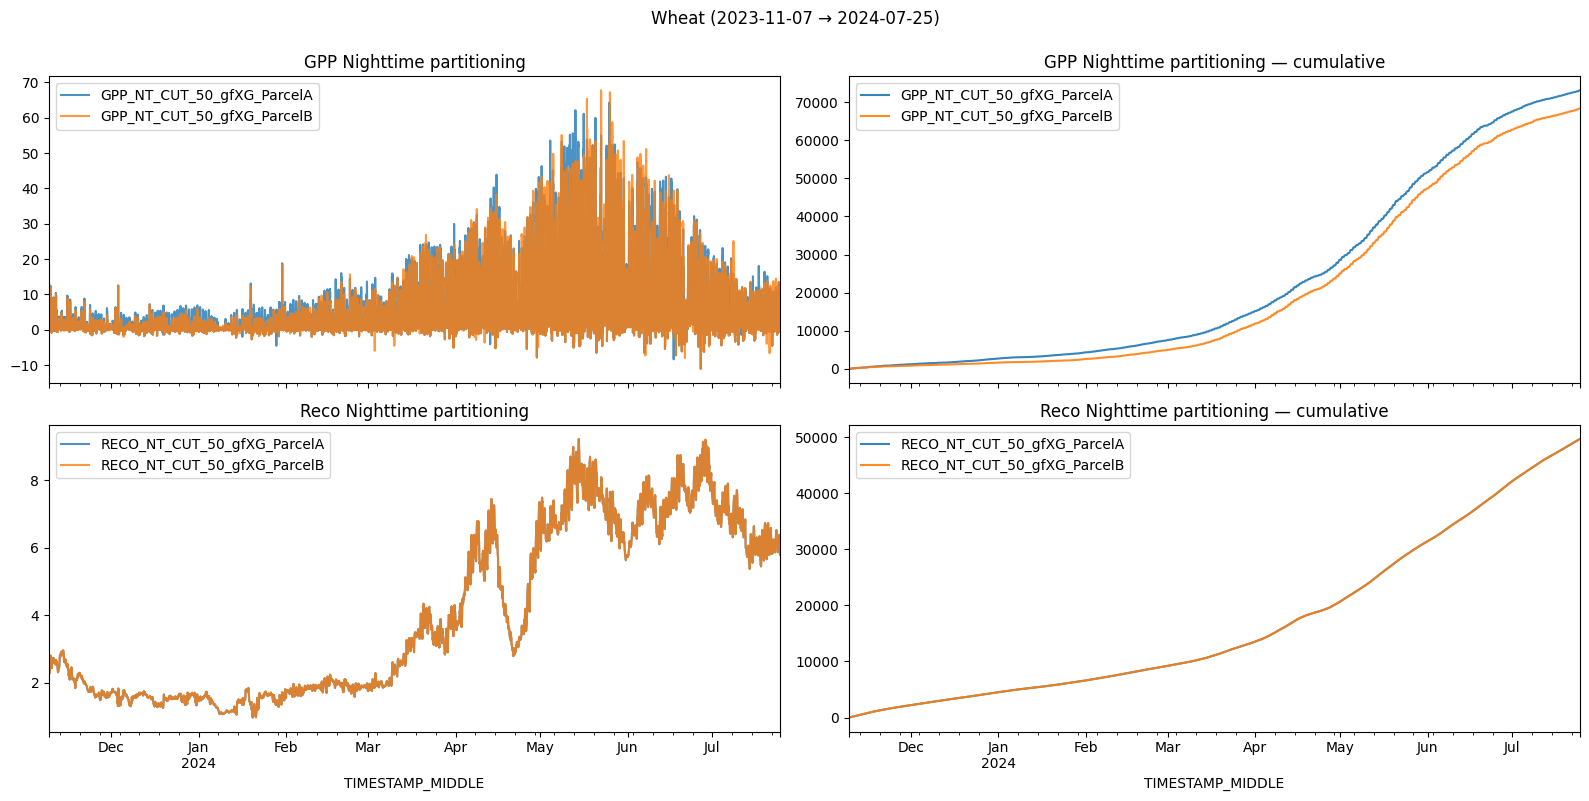

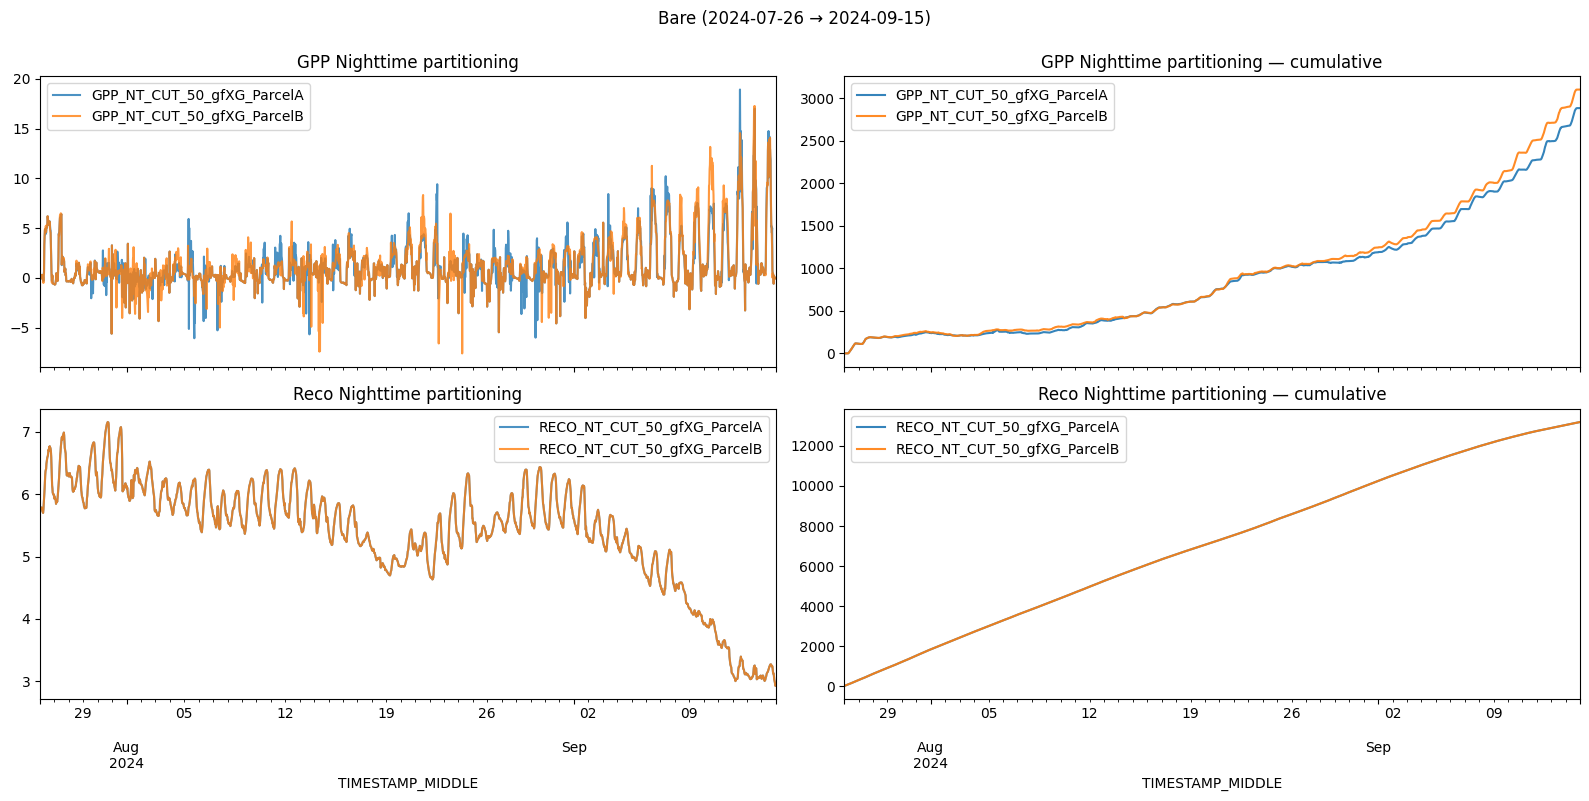

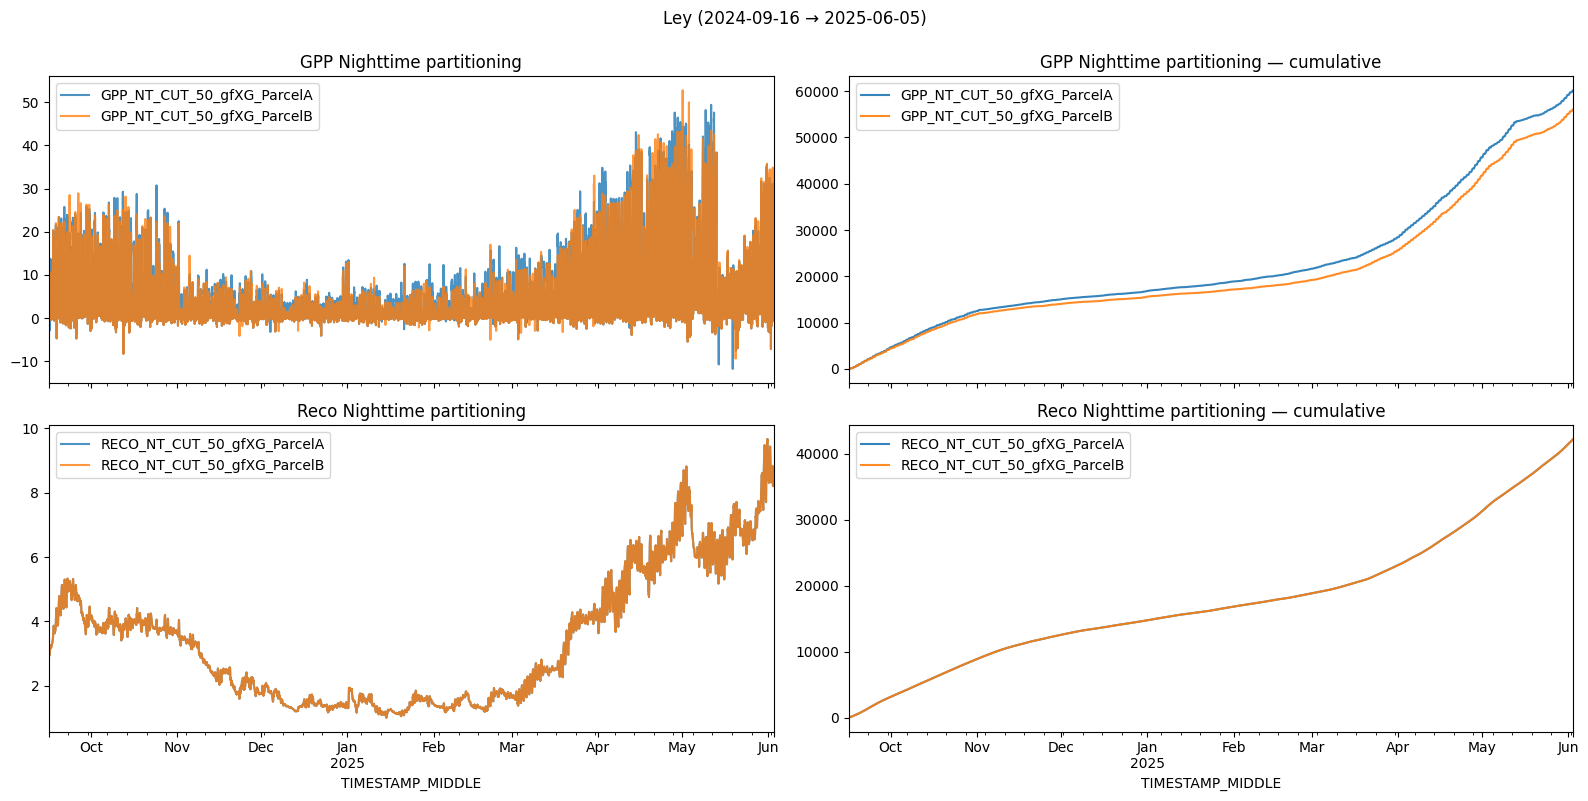

In [29]:
# Define periods
periods = [
    ("2023-11-07", "2024-07-25", "Wheat"),
    ("2024-07-26", "2024-09-15", "Bare"),
    ("2024-09-16", "2025-06-05", "Ley"),
]

# periods = [
#     ("2024-02-07", "2024-02-10", "Wheat"),
#     ("2024-08-01", "2024-08-04", "Bare"),
#     ("2025-03-16", "2025-03-29", "Ley"),
# ]

for start, end, label in periods:
    period_df = subset_partcols.loc[pd.to_datetime(start):pd.to_datetime(end)]
    PARCELS = ['A', 'B']
    pairs = [
        ([f"GPP_NT_CUT_50_gfXG_Parcel{p}" for p in PARCELS], "GPP Nighttime partitioning"),
        ([f"RECO_NT_CUT_50_gfXG_Parcel{p}" for p in PARCELS], "Reco Nighttime partitioning"),
#        ([f"GPP_DT_CUT_50_gfXG_Parcel{p}" for p in PARCELS], "GPP Daytime partitioning"),
#        ([f"RECO_DT_CUT_50_gfXG_Parcel{p}" for p in PARCELS], "Reco Daytime partitioning")
    ]

    # Keep only existing columns
    pairs = [(cols, t) for cols, t in pairs if all(c in period_df.columns for c in cols)]
    if not pairs: 
        continue

    nrows, ncols = len(pairs), 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows), sharex='col')
    if nrows == 1:  # make indexing uniform
        axes = axes.reshape(1, ncols)

    for r, (cols, t) in enumerate(pairs):
        # raw
        period_df[cols].plot(ax=axes[r, 0], alpha=0.8)
        axes[r, 0].set_title(f"{t}")

        # cumulative
        cumulative = period_df[cols].fillna(0).cumsum()
        cumulative.plot(ax=axes[r, 1], alpha=0.9)
        axes[r, 1].set_title(f"{t} — cumulative")

    fig.suptitle(f"{label} ({start} → {end})", y=0.995, fontsize=12)
    plt.tight_layout()
    plt.show()

# EXPORT DATA

In [30]:
filename = "87.1_PARTITIONED_FLUXES_GPP_RECO"
# subset_partcols.to_csv(f"{filename}.csv", index=True)
save_parquet(data=subset_partcols, filename=filename)

Saved file 87.1_PARTITIONED_FLUXES_GPP_RECO.parquet (0.033 seconds).


'87.1_PARTITIONED_FLUXES_GPP_RECO.parquet'

# End of notebook

In [31]:
from datetime import datetime
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-10-06 17:28:55
